# Test de différentes interpolations

## Imports & variables

In [91]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d, make_lsq_spline, BSpline
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import os
import glob
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

valeur_de_travail = 'T_Q'

fichier_nappe = "../data/fusion/data_03276X0009_P.csv"
dossier_nappe = "../data/fusion"

df = pd.read_csv(fichier_nappe, sep=";")

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').set_index('time')


df[valeur_de_travail] = pd.to_numeric(df[valeur_de_travail], errors='coerce')

x = np.arange(len(df))
y = df[valeur_de_travail].values

## Interpolations

### Interpolation linéaire

**Remarques :** Déjà utilisé par Ethienne.

In [92]:
def interpolation_lineaire_array(df, valeur_de_travail):
    """
    Interpole linéairement la colonne `valeur_de_travail`
    et renvoie le résultat sous forme de np.array.
    """
    return df[valeur_de_travail] \
        .interpolate(method='linear', limit_direction='both') \
        .to_numpy()

### Interpolation via spline cubique

**Remarques** : Formes interescente, à creser. 
Mauvais pour : l'ETP_Q

In [93]:
def interpolation_cubique_array(x, y):
    """
    Interpolation cubique avec extrapolation.
    Renvoie un np.array.
    """
    mask = ~np.isnan(y)
    f_cubic = interp1d(
        x[mask],
        y[mask],
        kind='cubic',
        fill_value="extrapolate"
    )
    return f_cubic(x)

### Interpolation via Polynômes de degré n

**Remarques :**
C'est pas très bon et en soit je pense qu'une ia marchera bien mieux pour combler les données qui manque

In [94]:
def interpolation_polynomiale_array(x, y, deg=2):
    """
    Ajustement polynomial et renvoie un np.array.
    """
    mask = ~np.isnan(y)
    x_known = x[mask]
    y_known = y[mask]

    coeffs = np.polyfit(x_known, y_known, deg=deg)
    poly_func = np.poly1d(coeffs)

    return poly_func(x)

### Interpolation via B-spline

In [95]:
def interpolation_spline_array(x, y, k=3, n_internal_knots=6):
    """
    Spline B par moindres carrés.
    Renvoie un np.array.
    """
    mask = ~np.isnan(y)
    x_known = x[mask]
    y_known = y[mask]

    sort_idx = np.argsort(x_known)
    x_sorted = x_known[sort_idx]
    y_sorted = y_known[sort_idx]

    knots_internal = np.linspace(
        x_sorted.min(),
        x_sorted.max(),
        n_internal_knots + 2
    )[1:-1]

    t = np.concatenate([
        np.full(k + 1, x_sorted.min()),
        knots_internal,
        np.full(k + 1, x_sorted.max())
    ])

    spl = make_lsq_spline(x_sorted, y_sorted, t, k)
    return spl(x)

### Interpolation via PCHIP

In [96]:
def interpolation_pchip_array(df, valeur_de_travail):
    """
    Interpolation PCHIP via pandas.
    Renvoie un np.array.
    """
    return (
        df[valeur_de_travail]
        .interpolate(method='pchip')
        .to_numpy()
    )

### Interpolation via akima

In [97]:
def interpolation_akima_array(df, valeur_de_travail):
    """
    Interpolation Akima via pandas.
    Renvoie un np.array.
    """
    return (
        df[valeur_de_travail]
        .interpolate(method='akima')
        .to_numpy()
    )

## Autres méthodes

### Random forest

In [98]:
def random_forest_delta_array(df, valeur_de_travail, features=None):
    if features is None:
        features = ['ETP_Q', 'T_Q']

    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)

    # 1. Calcul précis du temps écoulé en jours (même si c'est mensuel)
    # total_seconds / 86400 donne le nombre exact de jours entre deux relevés
    df['days_diff'] = df['time'].diff().dt.total_seconds() / 86400
    df['delta_niveaux'] = df[valeur_de_travail].diff()
    df['delta_per_day'] = df['delta_niveaux'] / df['days_diff']

    # 2. Nettoyage pour l'entraînement
    # On ne garde que les lignes où on a à la fois la cible et les features
    train_df = df.dropna(subset=[valeur_de_travail, 'delta_per_day'] + features)

    if len(train_df) < 3:
        # Si trop peu de données, on renvoie des NaN (le script passera au suivant)
        return np.full(len(df), np.nan)

    # 3. Modèle
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(train_df[features], train_df['delta_per_day'])

    # 4. Prédiction des deltas (on remplace les features manquantes par la moyenne)
    X_all = df[features].fillna(train_df[features].mean())
    pred_delta_per_day = model.predict(X_all)

    # 5. Reconstruction itérative du signal
    y_reconstruit = df[valeur_de_travail].to_numpy().copy()

    # --- SÉCURITÉ PREMIÈRE VALEUR ---
    # Si la 1ère valeur est manquante, on cherche la 1ère connue pour reculer ou on prend la moyenne
    if np.isnan(y_reconstruit[0]):
        first_valid_idx = df[valeur_de_travail].first_valid_index()
        if first_valid_idx is not None:
            y_reconstruit[0] = df[valeur_de_travail].iloc[first_valid_idx]
        else:
            y_reconstruit[0] = train_df[valeur_de_travail].mean()

    # --- RECONSTRUCTION ---
    for i in range(1, len(y_reconstruit)):
        if np.isnan(y_reconstruit[i]):
            # On applique : Valeur_précédente + (Pente_prédite * Nb_jours_réels)
            d_days = df['days_diff'].iloc[i]
            y_reconstruit[i] = y_reconstruit[i-1] + (pred_delta_per_day[i] * d_days)

    return y_reconstruit

### KNN

In [111]:
def knn_impute(df, target_col, k=5, past_only=False):
    df = df.copy()
    
    # --- 1️⃣ Préparation des features ---
    df["time"] = pd.to_datetime(df["time"])
    df["year"] = df["time"].dt.year
    df["month"] = df["time"].dt.month
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    
    df = df.sort_values(["code_bss", "time"])
    
    # Calcul des lags (sur les données trouées pour éviter la triche !)
    df["lag1"] = df.groupby("code_bss")[target_col].shift(1)
    df["lag2"] = df.groupby("code_bss")[target_col].shift(2)
    
    features = ["lon", "lat", "year", "month_sin", "month_cos", 
                ]

    # --- 2️⃣ Séparation et Nettoyage ---
    # On définit 'complete' : les lignes où on a la cible ET toutes les features
    # C'est crucial pour le StandardScaler
    mask_complete = df[target_col].notna() & df[features].notna().all(axis=1)
    complete = df[mask_complete].copy()
    missing = df[df[target_col].isna()].copy()

    # Sécurité : Si pas assez de points pour le KNN
    if len(complete) < k:
        # On remplit avec la moyenne simple du fichier pour éviter le crash
        return df.fillna({target_col: df[target_col].mean()})

    # --- 3️⃣ Normalisation ---
    scaler = StandardScaler()
    # .values pour éviter le warning "feature names"
    complete_scaled = scaler.fit_transform(complete[features].values)

    # --- 4️⃣ Imputation ---
    for idx in missing.index:
        # On récupère les features de la ligne à remplir
        row_data = df.loc[[idx], features]
        
        # Si la ligne manque de features (ex: pas de lag), on passe ou on met la moyenne
        if row_data.isna().any().any():
            df.loc[idx, target_col] = complete[target_col].mean()
            continue
            
        row_scaled = scaler.transform(row_data.values)
        
        # Filtrage temporel si demandé
        if past_only:
            time_mask = complete["time"] < df.loc[idx, "time"]
            valid_subset = complete[time_mask]
            valid_scaled_subset = complete_scaled[time_mask.values]
            
            if len(valid_subset) < k: # Pas assez de passé ? On prend ce qu'on a
                if len(valid_subset) == 0: continue
                current_k = len(valid_subset)
            else:
                current_k = k
        else:
            valid_subset = complete
            valid_scaled_subset = complete_scaled
            current_k = k
        
        # Calcul de la distance Euclidienne : $d = \sqrt{\sum (x_i - y_i)^2}$
        distances = np.sqrt(((valid_scaled_subset - row_scaled)**2).sum(axis=1))
        k_idx = np.argsort(distances)[:current_k]
        
        # Moyenne des K plus proches voisins
        df.loc[idx, target_col] = valid_subset.iloc[k_idx][target_col].mean()
    
    return df

### Arbre décisionnel

### Bootstrap saisonnier

## Resultat

### Interpolations

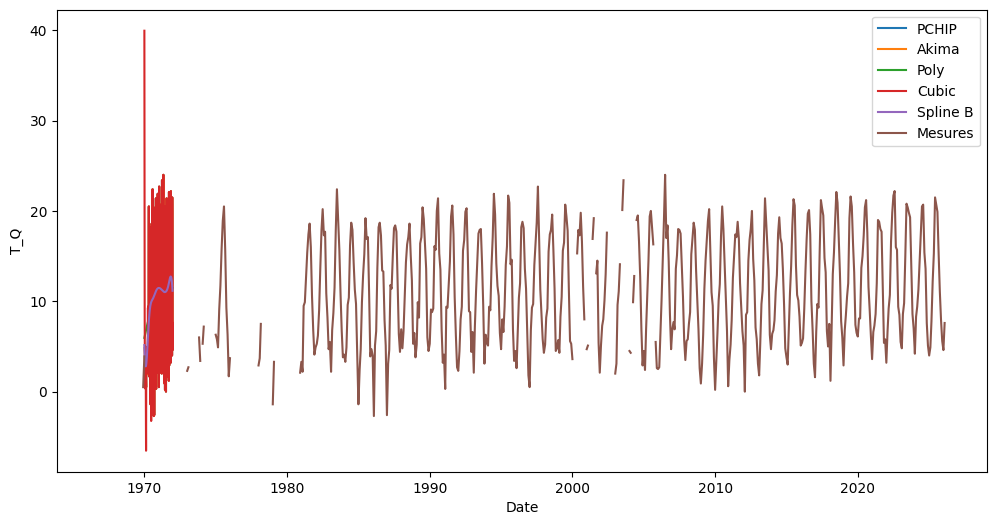

In [100]:
x = np.arange(len(df))
y = df[valeur_de_travail].to_numpy()

arr_cubic = interpolation_cubique_array(x, y)
arr_poly = interpolation_polynomiale_array(x, y, deg=2)
arr_spline = interpolation_spline_array(x, y)
arr_pchip = interpolation_pchip_array(df, valeur_de_travail)
arr_akima = interpolation_akima_array(df, valeur_de_travail)

# model, arr_rf = random_forest_delta_array(df, valeur_de_travail)

methods = {
    
    "PCHIP": arr_pchip,
    "Akima": arr_akima,
    "Poly": arr_poly,
    "Cubic": arr_cubic,
    "Spline B": arr_spline,
    "Mesures": df[valeur_de_travail],
    # "RF": arr_rf
}

plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(arr, label=label)
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.show()

### Autres méthodes

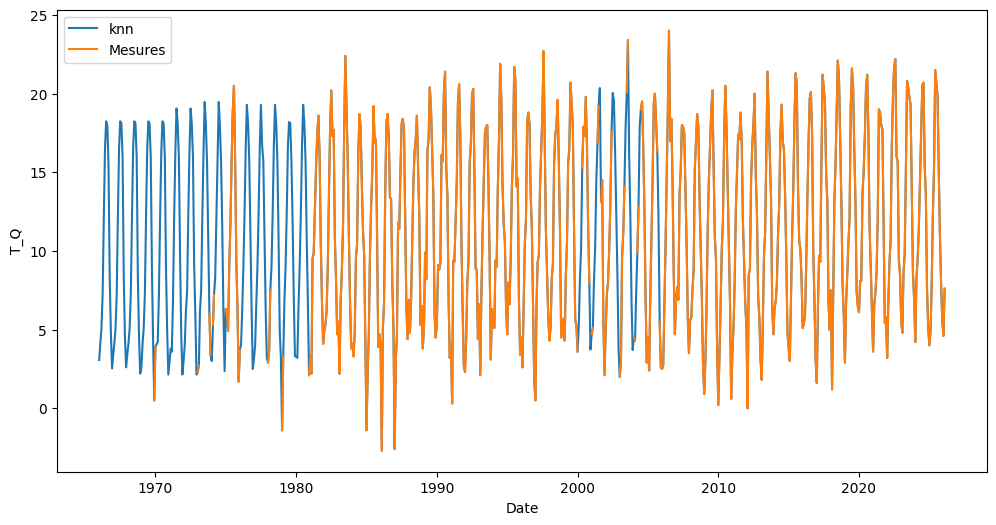

In [112]:
x = np.arange(len(df))
y = df[valeur_de_travail].to_numpy()

if "time" not in df.columns:
    df = df.reset_index()

knn = knn_impute(df, valeur_de_travail, k=7)

methods = {
    "knn": knn[valeur_de_travail],
    "Mesures": df[valeur_de_travail],
}

plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(df['time'],arr, label=label)
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.show()

## Tests

### MAE - Mean Absolute Error

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

Où :

- $y_i$ : valeur observée  
- $\hat{y}_i$ : valeur prédite  
- $n$ : nombre d'observations  

In [102]:
def nmae(prediction, reelle):
    range_val = np.max(reelle) - np.min(reelle)
    if range_val == 0: return 0 # Sécurité si le signal est plat
    return np.mean(np.abs(reelle - prediction)) / range_val

### RMSE - Root Mean Square Error

$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 }
$$

Où :

- $y_i$ : valeur observée  
- $\hat{y}_i$ : valeur prédite  
- $n$ : nombre d'observations  

In [103]:
def nrmse(prediction, reelle):
    range_val = np.max(reelle) - np.min(reelle)
    if range_val == 0: return 0
    # On calcule la RMSE standard puis on normalise
    return np.sqrt(np.mean((reelle - prediction) ** 2)) / range_val

### NSE - Nash–Sutcliffe Efficiency

$$
\text{NSE} = 1 - 
\frac{
\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
}{
\sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2
}
$$

Où :

- $y_i$ : valeur observée  
- $\hat{y}_i$ : valeur prédite  
- $\bar{y}$ : moyenne des valeurs observées  
- $n$ : nombre d'observations  

In [104]:
def nse(prediction, reelle):    
    numerator = np.sum((reelle - prediction) ** 2)
    denominator = np.sum((reelle - np.mean(reelle)) ** 2)
    
    if denominator == 0:
        return np.nan
    
    return 1 - (numerator / denominator)

### Visuels

In [105]:
def get_csv_files(folder_path):
    pattern = os.path.join(folder_path, "*.csv")
    files = glob.glob(pattern)

    if not files:
        print(f"❌ Aucun fichier CSV trouvé dans : {folder_path}")
        return []

    return files

def prepare_dataset(file, valeur_de_travail, remove_pct, rng):
    ds_name = os.path.basename(file)

    df = pd.read_csv(file, sep=';')

    if valeur_de_travail not in df.columns:
        print(f"⚠️ {ds_name} ignoré : colonne absente.")
        return None

    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)

    y_full = df[valeur_de_travail].to_numpy()

    if np.isnan(y_full).all():
        print(f"⚠️ {ds_name} ignoré : uniquement des NaN.")
        return None

    n_points = len(df)

    if remove_pct > 0:
        n_remove = int(n_points * remove_pct)
        remove_idx = rng.choice(n_points, size=n_remove, replace=False)
        y = y_full.copy()
        y[remove_idx] = np.nan
    else:
        y = y_full.copy()

    if np.count_nonzero(~np.isnan(y)) < 4:
        print(f"⚠️ {ds_name} ignoré : pas assez de points valides.")
        return None

    return df, y_full, y, ds_name

def compute_interpolations(df, y, valeur_de_travail):
    x = np.arange(len(df))

    df_with_holes = df.copy()
    df_with_holes[valeur_de_travail] = y

    methods = {
        "Linear": pd.Series(y).interpolate(method='linear', limit_direction='both').to_numpy(),
        "PCHIP": interpolation_pchip_array(
            pd.DataFrame({'time': df['time'], valeur_de_travail: y}),
            valeur_de_travail
        ),
        "Akima": interpolation_akima_array(
            pd.DataFrame({'time': df['time'], valeur_de_travail: y}),
            valeur_de_travail
        ),
        "Cubic": interpolation_cubique_array(x, y),
        "KNN": knn_impute(df_with_holes, valeur_de_travail, k=5)[valeur_de_travail].to_numpy()
        
    }

    return methods

def evaluate_methods(methods_dict, y_full, ds_name, remove_pct):
    rows = []

    for method_name, arr in methods_dict.items():
        rows.append({
            'dataset': ds_name,
            'method': method_name,
            'pct_removed': remove_pct,
            'NMAE': nmae(arr, y_full),
            'NRMSE': nrmse(arr, y_full)
        })

    return rows

def evaluate_all_files(folder_path, valeur_de_travail,
                       remove_pct_list=[0.1],
                       random_state=42,
                       max_files=1000):

    files = get_csv_files(folder_path)
    if not files:
        return None

    rng = np.random.default_rng(random_state)
    all_rows = []
    processed_count = 0

    for remove_pct in remove_pct_list:
        for file in files:
            if processed_count >= max_files:
                break

            try:
                prepared = prepare_dataset(file, valeur_de_travail, remove_pct, rng)
                if prepared is None:
                    continue

                df, y_full, y, ds_name = prepared

                methods = compute_interpolations(df, y, valeur_de_travail)

                rows = evaluate_methods(methods, y_full, ds_name, remove_pct)
                all_rows.extend(rows)

                processed_count += 1

            except Exception as e:
                print(f"💥 Erreur sur {file} : {e}")
                continue

    if not all_rows:
        print("🛑 Aucun fichier traité.")
        return None

    return pd.DataFrame(all_rows)

def plot_scatter_zooms(error_df, processed_count):
    methods_unique = error_df['method'].unique()
    palette = sns.color_palette("tab10", n_colors=len(methods_unique))
    markers = ['o', '^', 's', 'D', 'v', 'P', 'X', '*']

    zooms = [0.5, 0.05, 0.005]

    for z_limit in zooms:
        plt.figure(figsize=(10, 6))

        for i, method in enumerate(methods_unique):
            sub = error_df[error_df['method'] == method]
            plt.scatter(sub['NMAE'], sub['NRMSE'],
                        color=palette[i],
                        marker=markers[i],
                        s=100,
                        edgecolor='k',
                        alpha=0.6,
                        label=method)

        plt.xlim(0, z_limit)
        plt.ylim(0, z_limit)
        plt.xlabel("NMAE")
        plt.ylabel("NRMSE")
        plt.title(f"Zoom [0 - {z_limit}] ({processed_count} fichiers)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def compute_ranking_stats(error_df):
    error_df = error_df.copy()
    error_df['rank'] = error_df.groupby(['dataset', 'pct_removed'])['NMAE'].rank(method='min')

    stats = []

    methods = error_df['method'].unique()
    n_meth = len(methods)

    for method in methods:
        m_df = error_df[error_df['method'] == method]
        stats.append({
            'method': method,
            'Premier': (m_df['rank'] == 1).sum(),
            'Dernier': (m_df['rank'] == n_meth).sum(),
            'rank_moyen': m_df['rank'].mean()
        })

    return pd.DataFrame(stats)

def plot_first_vs_last(stats_df, processed_count):
    plt.figure(figsize=(10, 7))

    methods = stats_df['method'].unique()
    palette = sns.color_palette("tab10", n_colors=len(methods))
    markers = ['o', '^', 's', 'D', 'v', 'P', 'X', '*']

    for i, method in enumerate(methods):
        row = stats_df[stats_df['method'] == method]

        x_val = row['Premier'].iloc[0]
        y_val = row['Dernier'].iloc[0]

        plt.scatter(
            x_val,
            y_val,
            color=palette[i],
            marker=markers[i],
            s=250,
            edgecolor='k',
            label=method
        )

        plt.text(x_val + 0.1, y_val + 0.1,
                 method,
                 fontsize=10,
                 fontweight='bold')

    plt.xlabel("Nombre de fois arrivée 1er")
    plt.ylabel("Nombre de fois arrivée dernier")
    plt.title(f"Fiabilité relative des méthodes\n(Total datasets : {processed_count})")

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_first_vs_avg_rank(stats_df, processed_count):
    plt.figure(figsize=(10, 7))

    methods = stats_df['method'].unique()
    palette = sns.color_palette("tab10", n_colors=len(methods))
    markers = ['o', '^', 's', 'D', 'v', 'P', 'X', '*']

    for i, method in enumerate(methods):
        row = stats_df[stats_df['method'] == method]

        x_val = row['Premier'].iloc[0]
        y_val = row['rank_moyen'].iloc[0]

        plt.scatter(
            x_val,
            y_val,
            color=palette[i],
            marker=markers[i],
            s=250,
            edgecolor='k',
            label=method
        )

        plt.text(x_val + 0.1, y_val + 0.02,
                 method,
                 fontsize=10,
                 fontweight='bold')

    plt.xlabel("Nombre de victoires (1er)")
    plt.ylabel("Rang moyen (plus petit = meilleur)")
    plt.title(f"Performance globale\n(Sur {processed_count} fichiers)")

    plt.gca().invert_yaxis()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_dataset_focus(error_df, target_dataset_name):
    df_graph = error_df[error_df['dataset'] == target_dataset_name]

    if df_graph.empty:
        print(f"⚠️ Dataset {target_dataset_name} non trouvé.")
        return

    plt.figure(figsize=(12, 8))

    methods = df_graph['method'].unique()
    pct_values = sorted(df_graph['pct_removed'].unique())

    palette = sns.color_palette("husl", n_colors=len(methods))
    markers = ['o', '^', 's', 'D', 'v', 'P', 'X', '*']

    marker_map = {
        pct: markers[i % len(markers)]
        for i, pct in enumerate(pct_values)
    }

    for i, method in enumerate(methods):
        for pct in pct_values:
            subset = df_graph[
                (df_graph['method'] == method) &
                (df_graph['pct_removed'] == pct)
            ]

            if not subset.empty:
                plt.scatter(
                    subset['NRMSE'],
                    subset['NMAE'],
                    color=palette[i],
                    marker=marker_map[pct],
                    s=150,
                    edgecolor='black',
                    linewidth=1,
                    alpha=0.9
                )

    # --- LÉGENDES ---
    from matplotlib.lines import Line2D

    legend_methods = [
        Line2D([0], [0],
               marker='o',
               color='w',
               label=m,
               markerfacecolor=palette[i],
               markersize=10)
        for i, m in enumerate(methods)
    ]

    legend_pct = [
        Line2D([0], [0],
               marker=marker_map[p],
               color='w',
               label=f"{int(p*100)}% trous",
               markerfacecolor='gray',
               markersize=10)
        for p in pct_values
    ]

    l1 = plt.legend(
        handles=legend_methods,
        title="Méthodes",
        loc='upper left',
        bbox_to_anchor=(1, 1)
    )
    plt.gca().add_artist(l1)

    plt.legend(
        handles=legend_pct,
        title="% données retirées",
        loc='lower left',
        bbox_to_anchor=(1, 0)
    )

    plt.xlabel("NRMSE (sensibilité aux grosses erreurs)")
    plt.ylabel("NMAE (erreur moyenne globale)")
    plt.title(f"Analyse de robustesse : {target_dataset_name}")

    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def run_full_evaluation(folder_path,
                        valeur_de_travail,
                        remove_pct_list=[0.1],
                        random_state=42,
                        target_dataset_name=None):
    
    print(f"""
============================================================================\n
\n
                            {valeur_de_travail}\n
\n
============================================================================\n
""")

    error_df = evaluate_all_files(
        folder_path,
        valeur_de_travail,
        remove_pct_list,
        random_state
    )

    if error_df is None:
        return None

    processed_count = error_df['dataset'].nunique()

    # Graph 1 & 2
    plot_scatter_zooms(error_df, processed_count)

    # Ranking
    stats_df = compute_ranking_stats(error_df)

    # Graph 3
    plot_first_vs_last(stats_df, processed_count)

    # Graph 4
    plot_first_vs_avg_rank(stats_df, processed_count)

    # Graph 5
    if target_dataset_name is None:
        target_dataset_name = error_df['dataset'].iloc[0]

    plot_dataset_focus(error_df, target_dataset_name)

    return error_df, stats_df






                            T_Q





⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.
⚠️ data_03295X1035_S1.csv ignoré : pas assez de points valides.
⚠️ data_03651X0043_S1.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.
⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.
⚠️ data_03295X1035_S1.csv ignoré : pas assez de points valides.
⚠️ data_03651X0043_S1.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.
⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.
⚠️ data_03283X0057_F.csv ignoré : pas assez de points valides.
⚠️ data_03295X1035_S1.csv ignoré : pas assez de points valides.
⚠️ data_03651X0043_S1.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.
⚠️ data_04002X0015_F1.csv ignoré : pas assez de points valides.
⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.


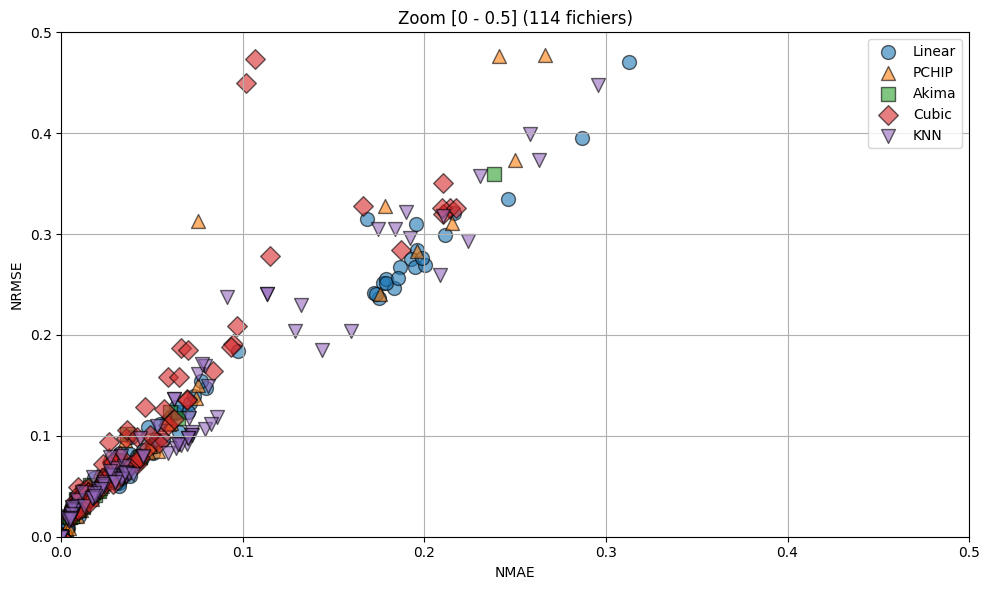

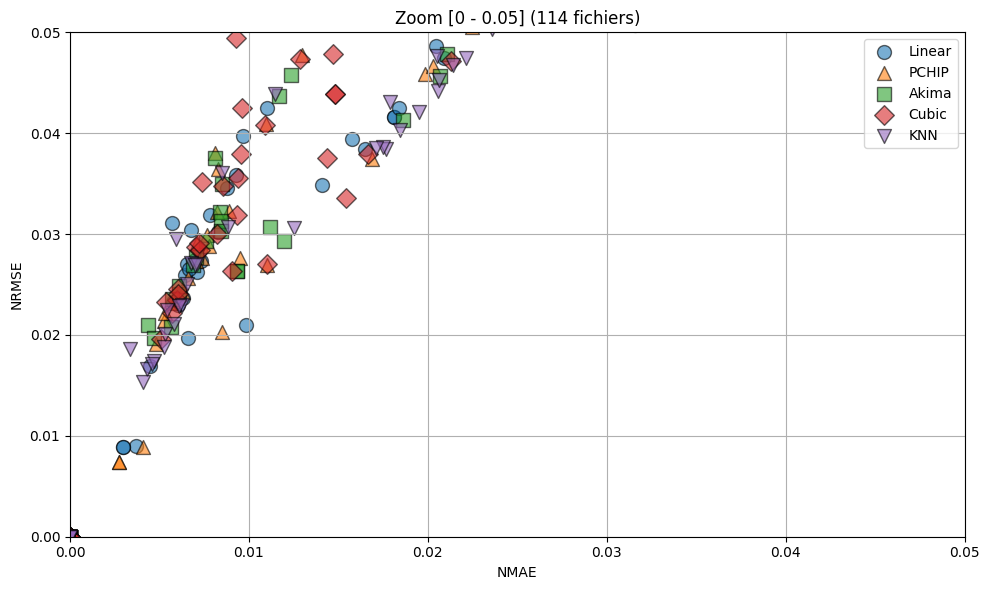

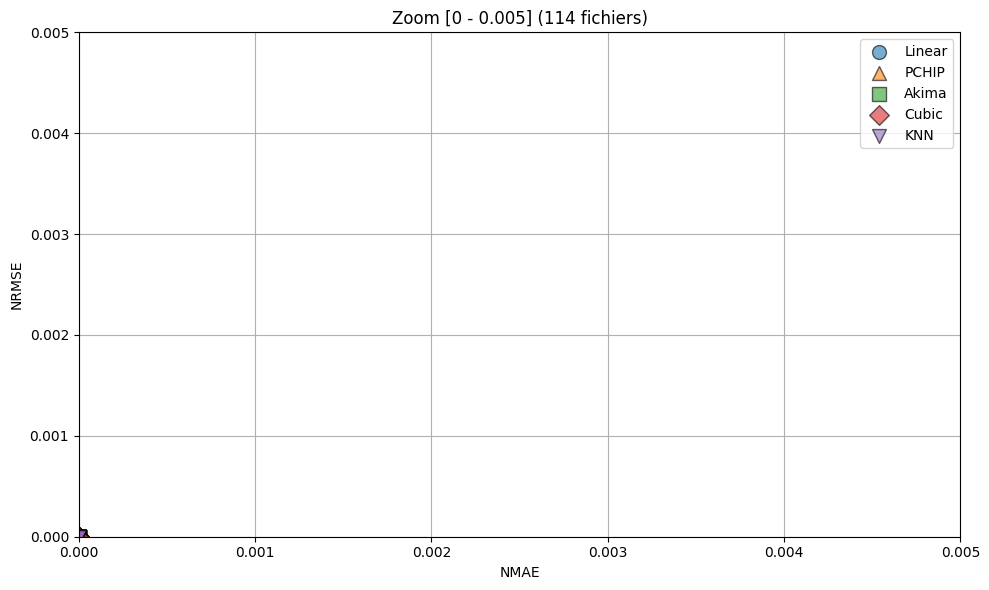

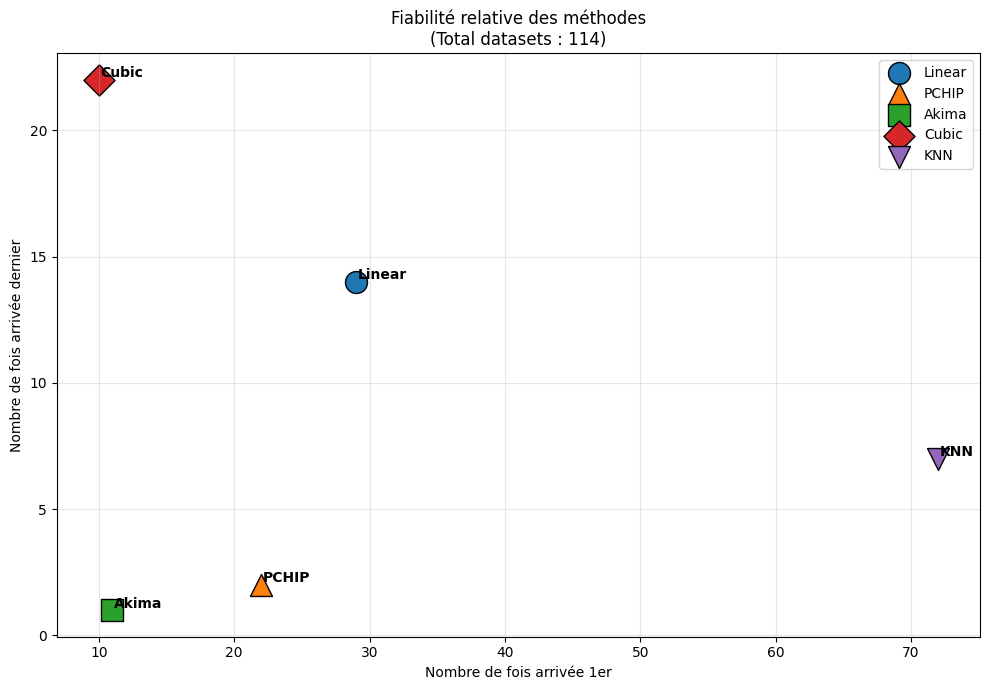

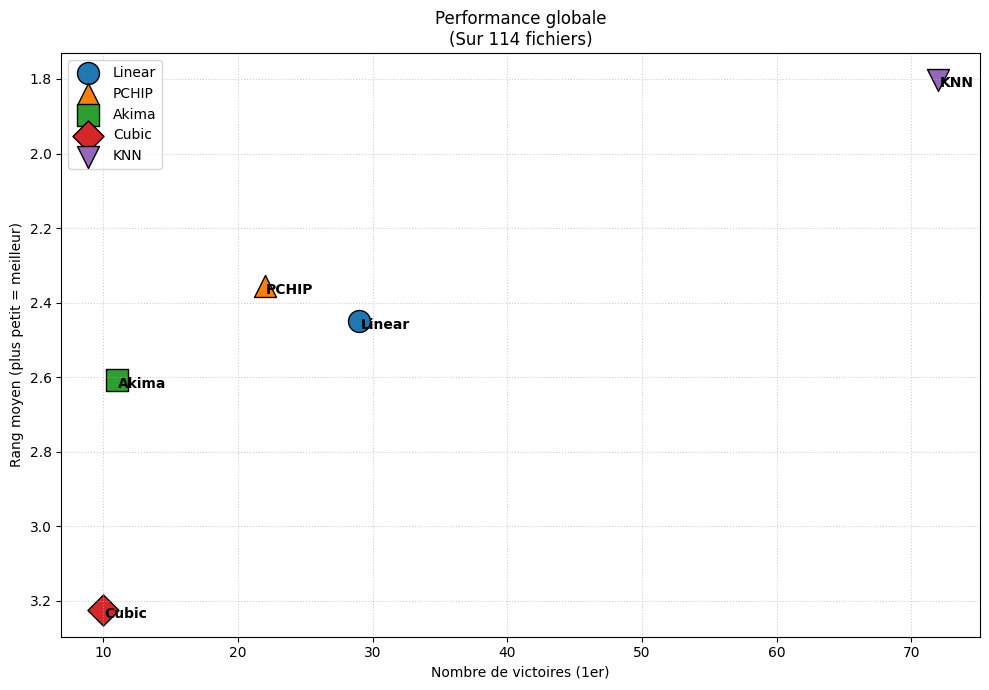

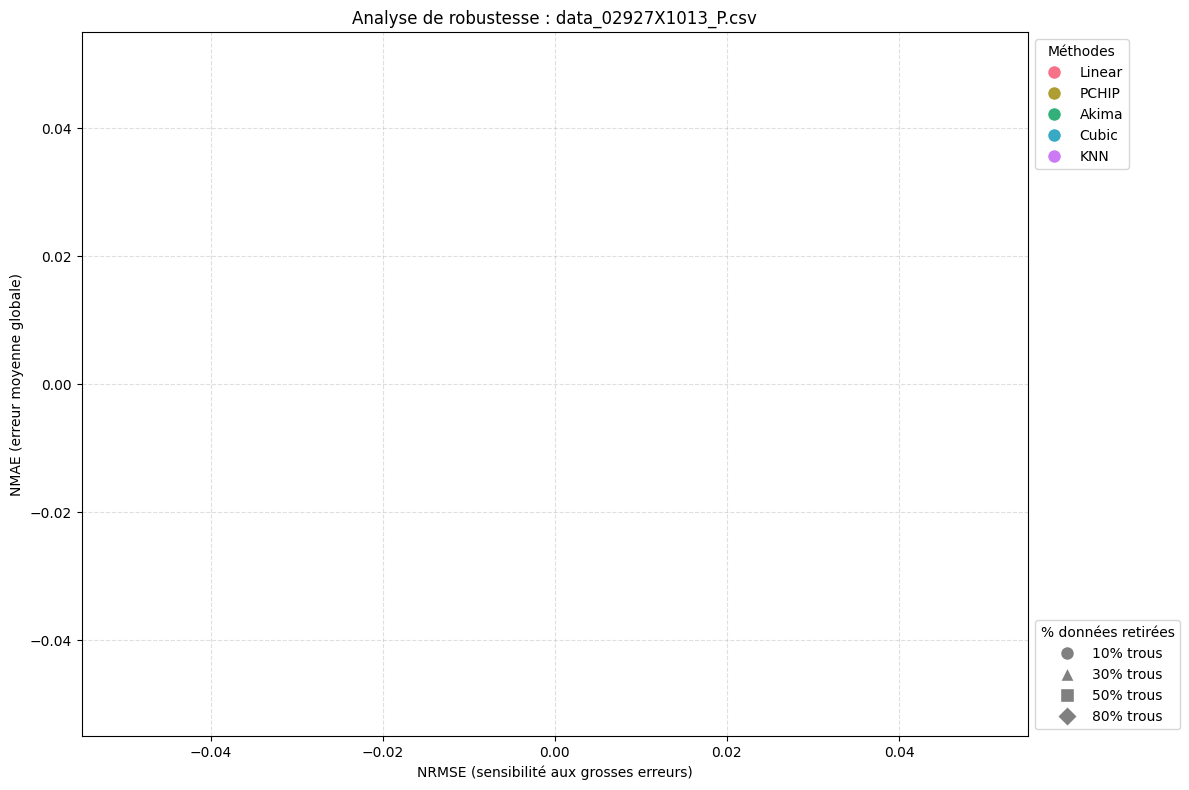





                            niveau_nappe_eau





⚠️ data_03283X0057_F.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.


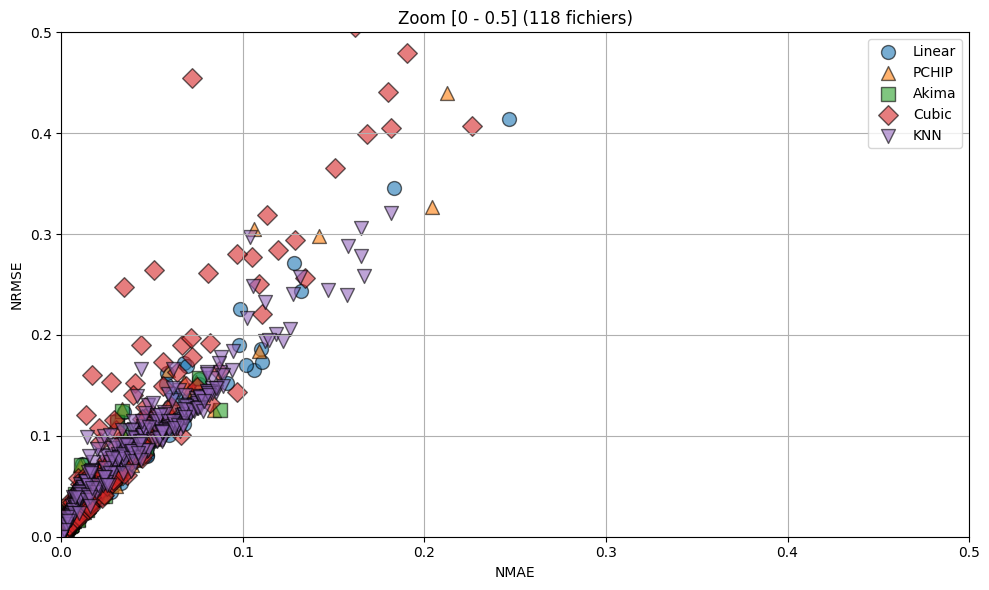

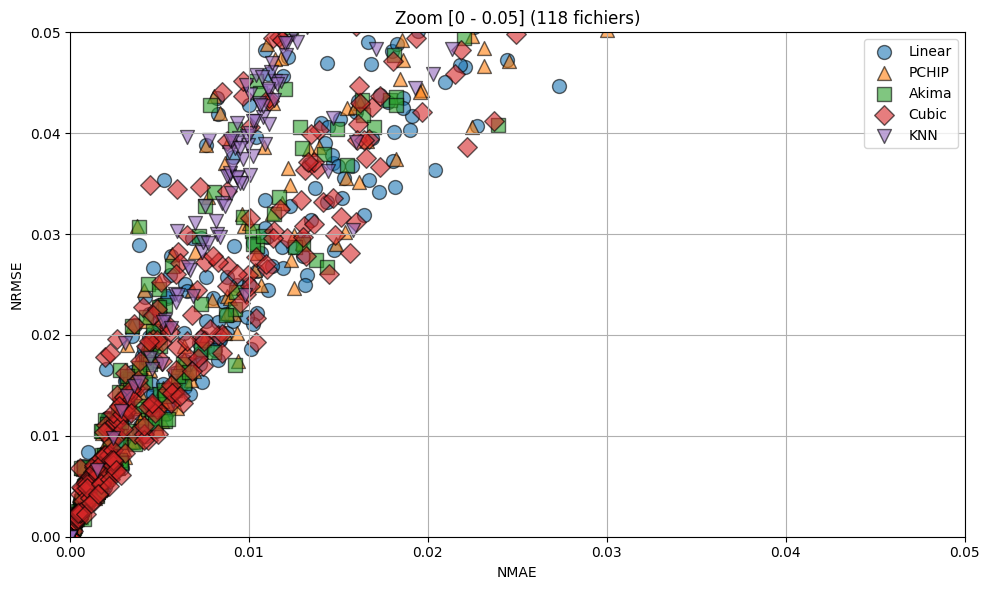

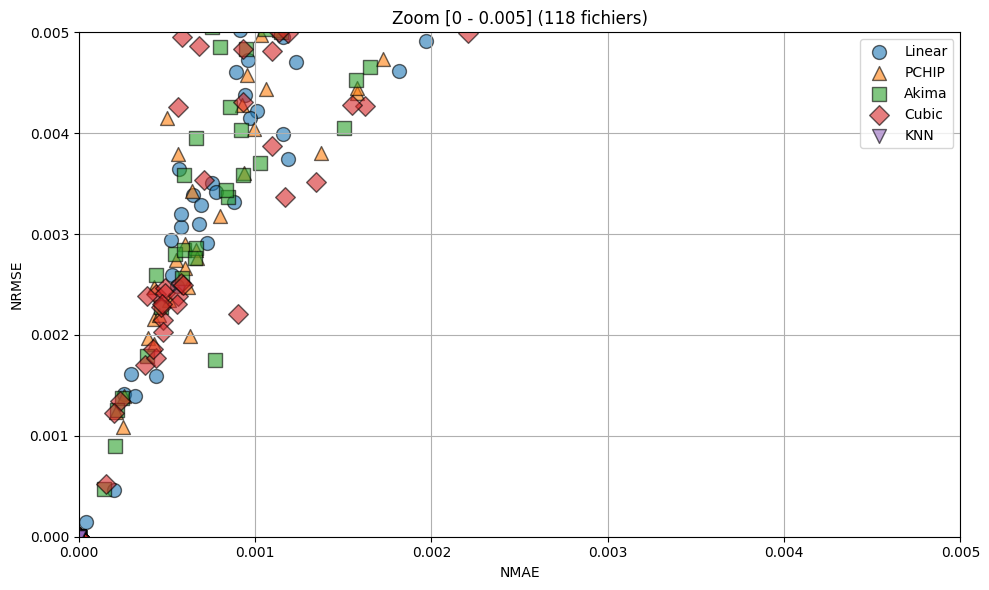

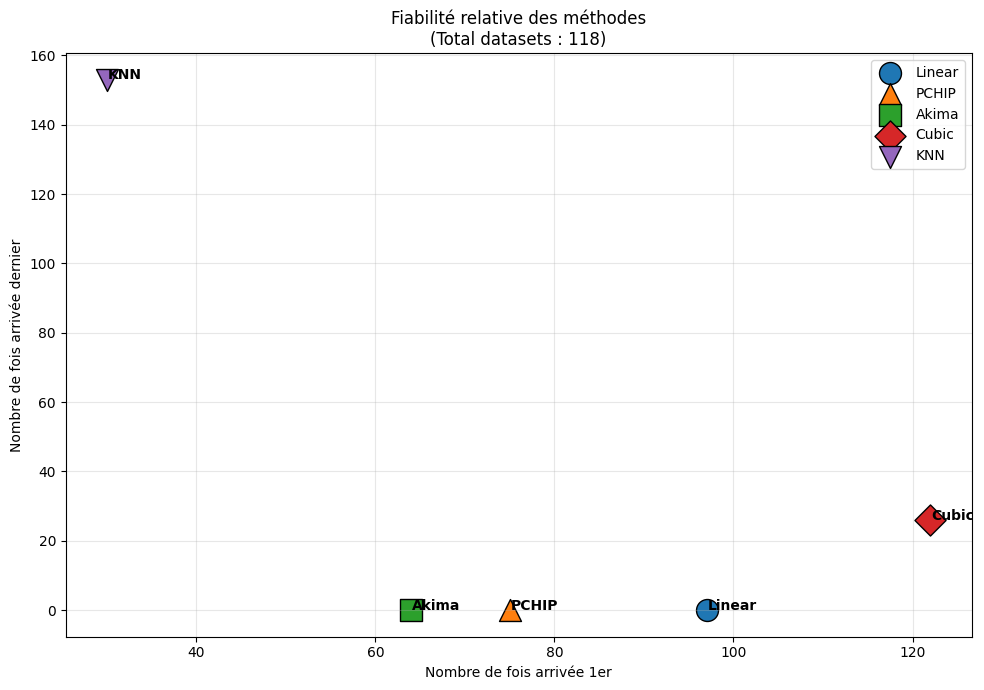

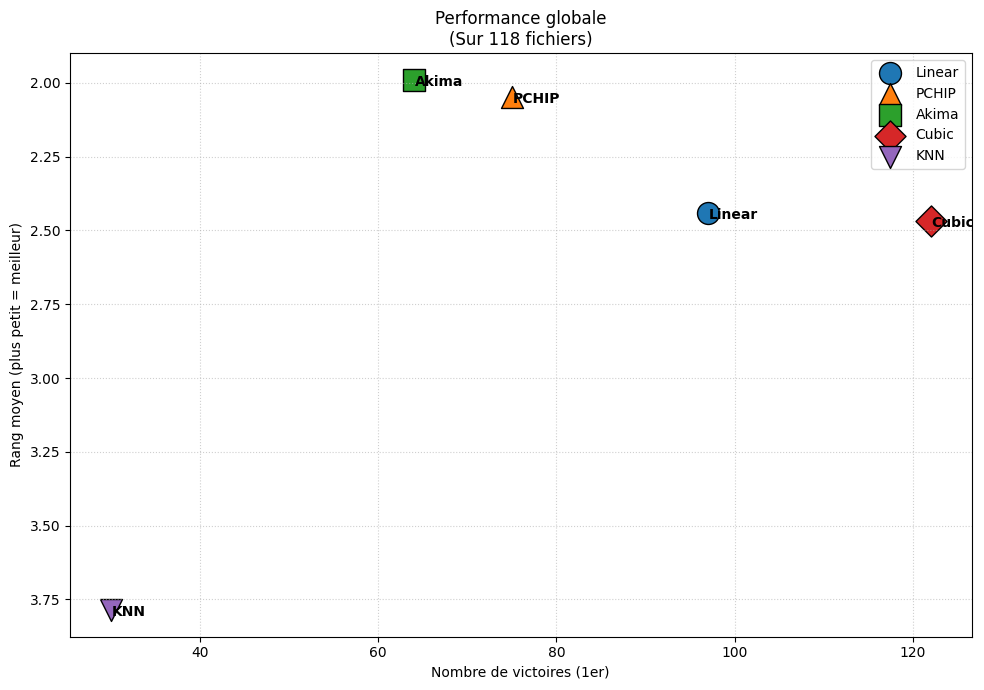

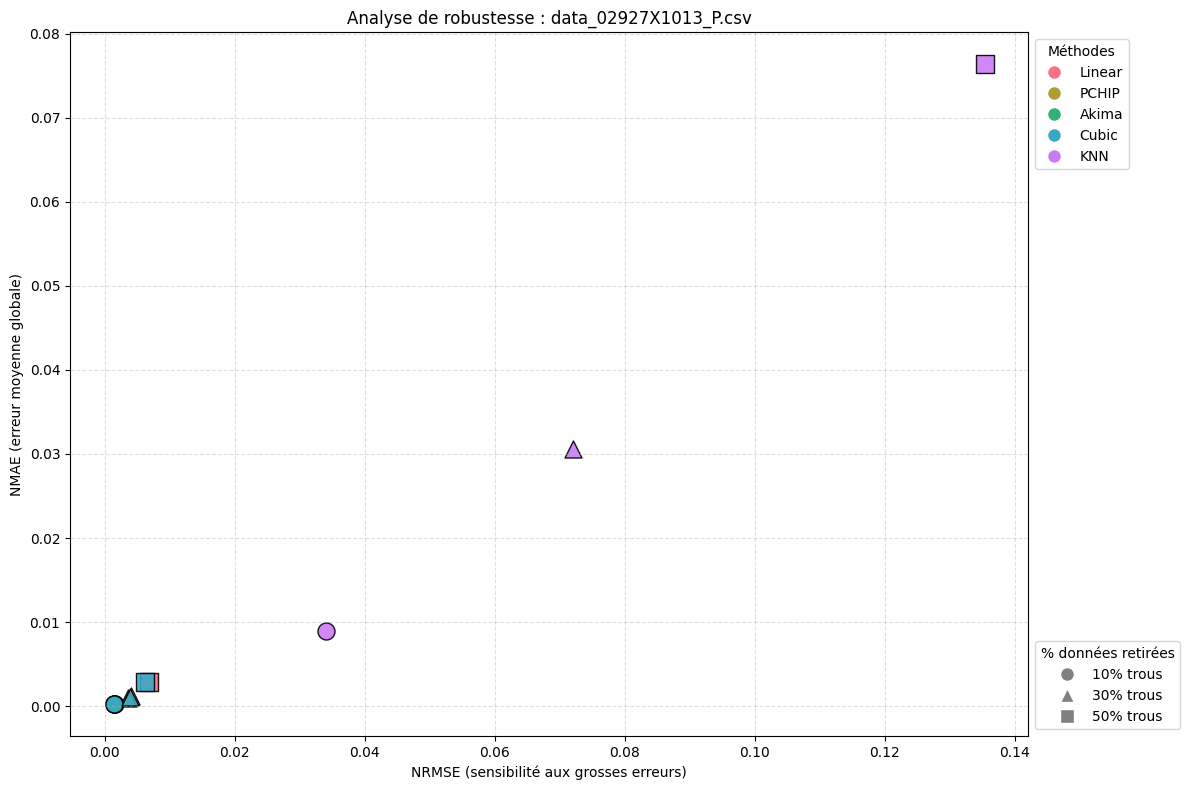





                            ETP_Q





⚠️ data_03283X0057_F.csv ignoré : uniquement des NaN.
⚠️ data_03283X0060_F.csv ignoré : uniquement des NaN.
⚠️ data_03288X0096_F.csv ignoré : uniquement des NaN.
⚠️ data_03296X1015_P.csv ignoré : uniquement des NaN.
⚠️ data_03624X0088_F.csv ignoré : uniquement des NaN.
⚠️ data_03641X0078_F.csv ignoré : uniquement des NaN.
⚠️ data_03645X0161_F.csv ignoré : uniquement des NaN.
⚠️ data_03655X0031_P.csv ignoré : uniquement des NaN.
⚠️ data_03656X0017_PF.csv ignoré : uniquement des NaN.
⚠️ data_04001X0113_F.csv ignoré : uniquement des NaN.
⚠️ data_BSS004LLWY_X.csv ignoré : uniquement des NaN.
⚠️ data_BSS004NBLL_X.csv ignoré : uniquement des NaN.
⚠️ data_03283X0057_F.csv ignoré : uniquement des NaN.
⚠️ data_03283X0060_F.csv ignoré : uniquement des NaN.
⚠️ data_03288X0096_F.csv ignoré : uniquement des NaN.
⚠️ data_03296X1015_P.csv ignoré : uniquement des NaN.
⚠️ data_03624X0088_F.csv ignoré : uniquement des NaN.
⚠️ data_03641X0078_F.csv ignoré : uniq

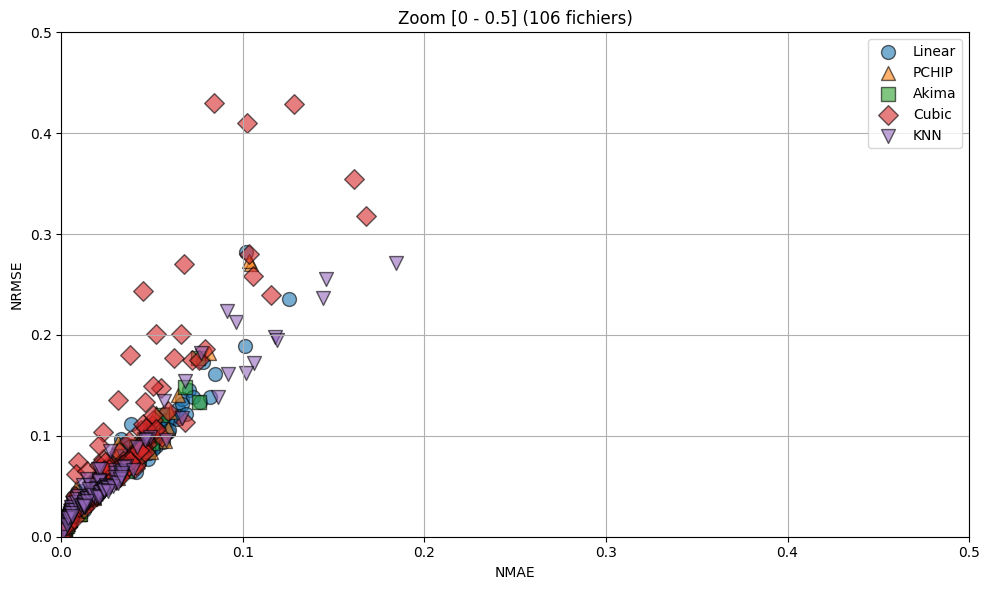

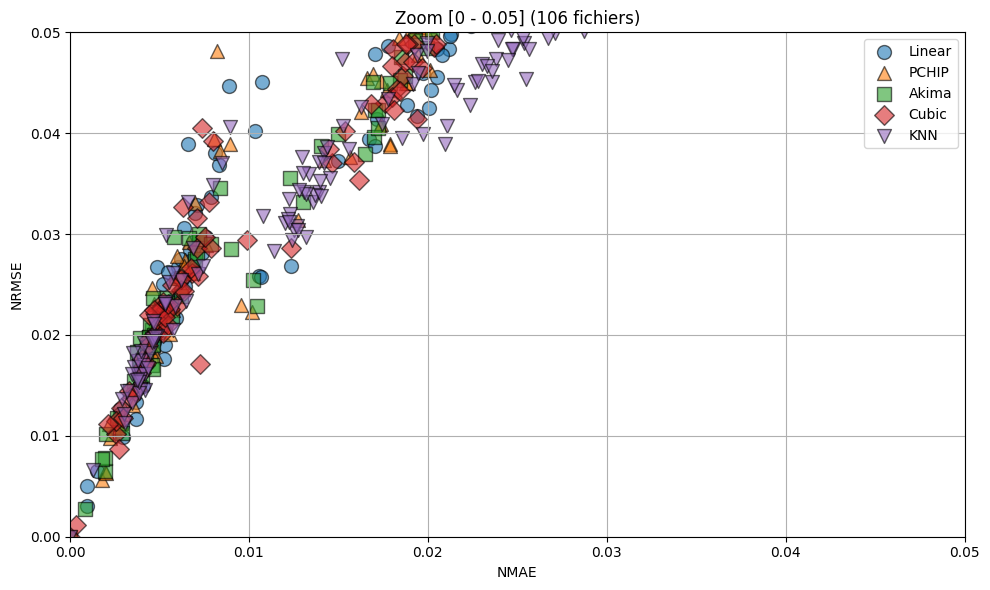

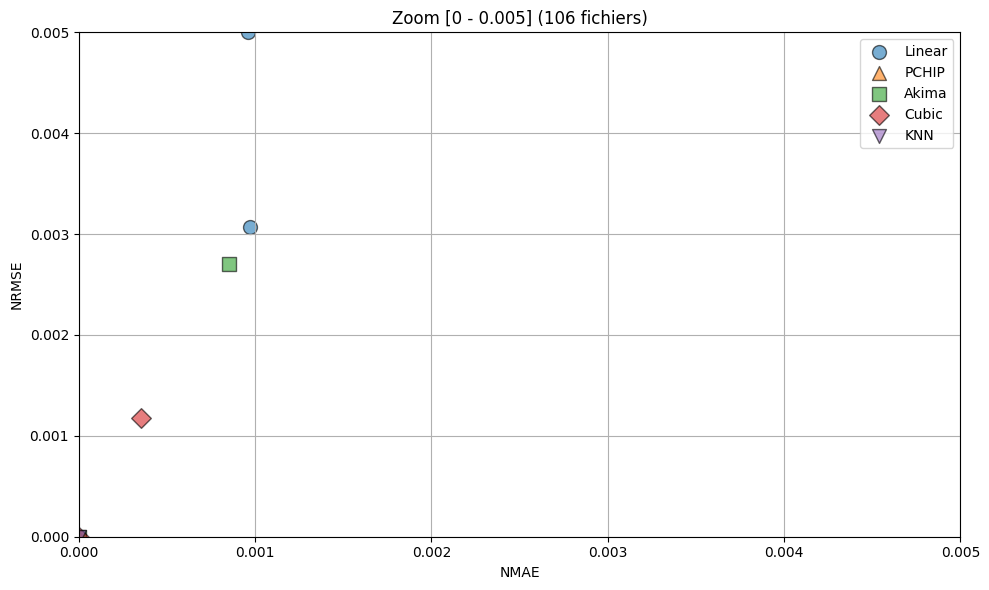

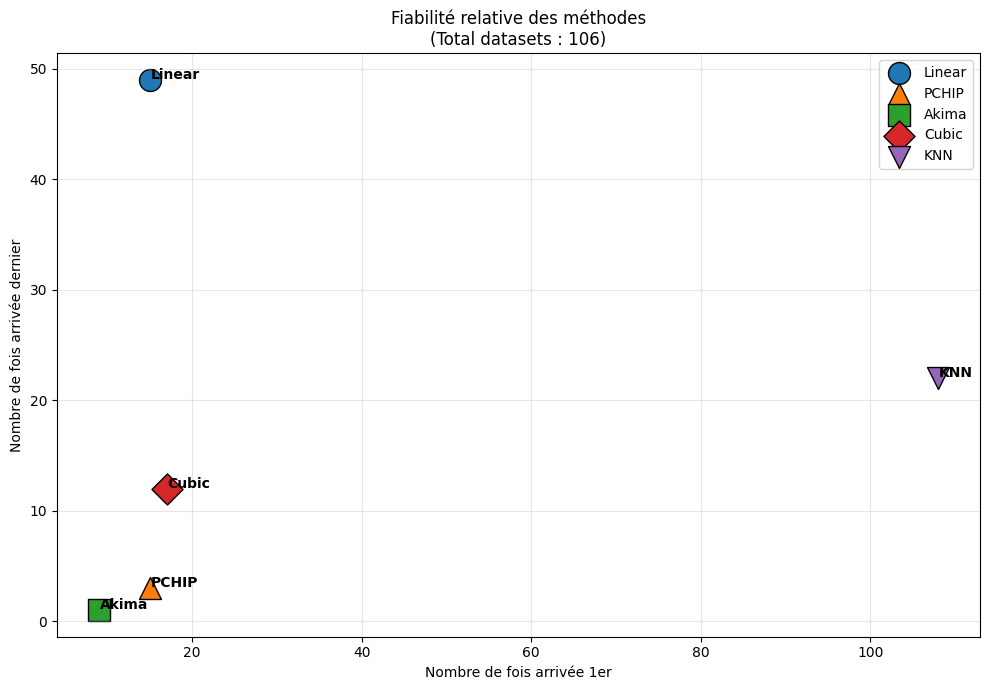

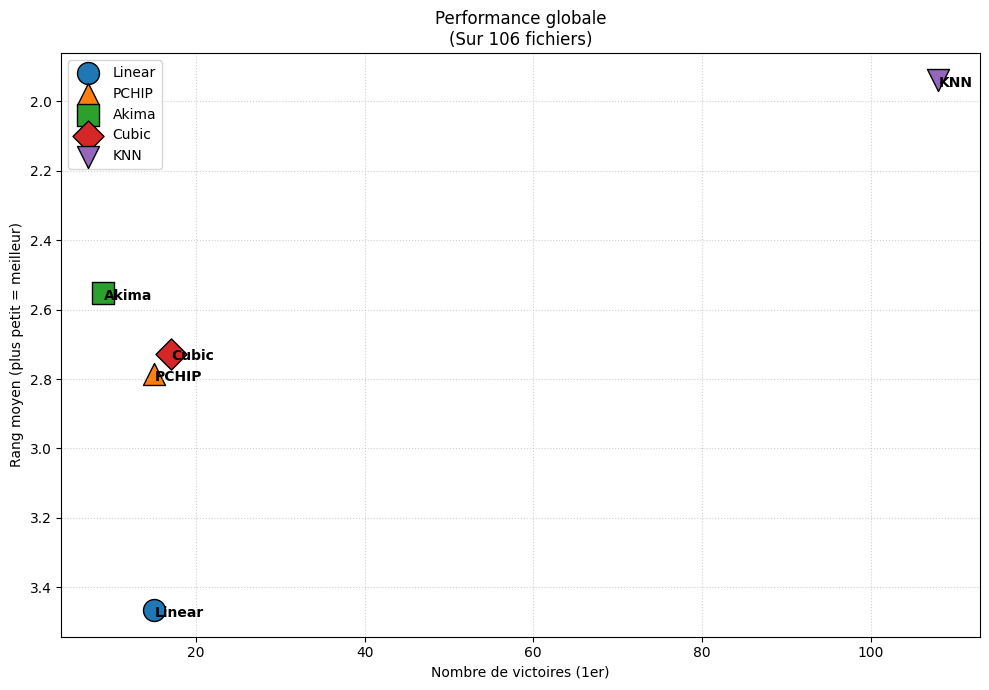

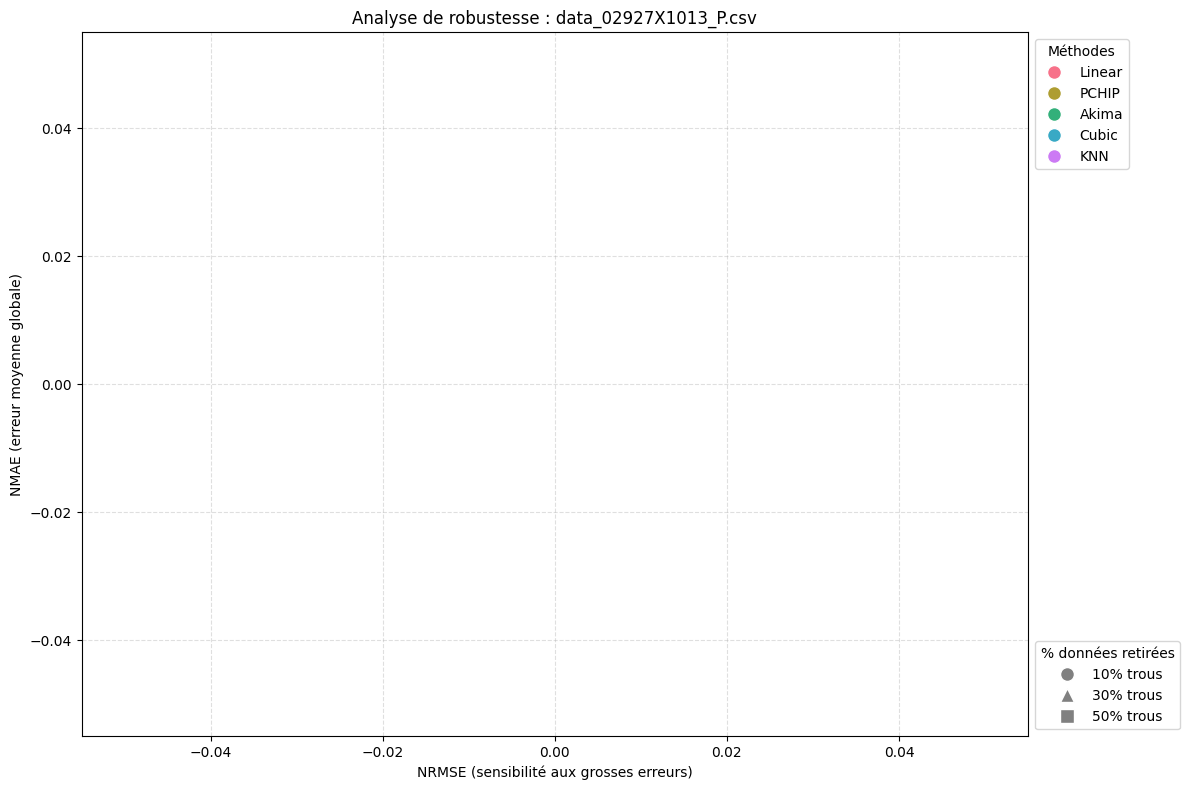





                            PRELIQ_Q





⚠️ data_03283X0057_F.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.


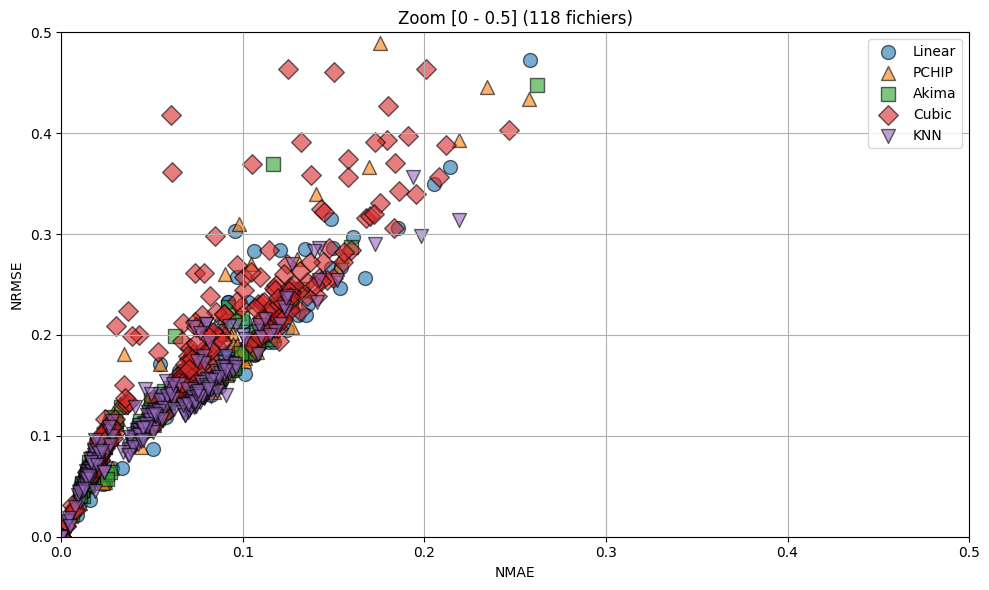

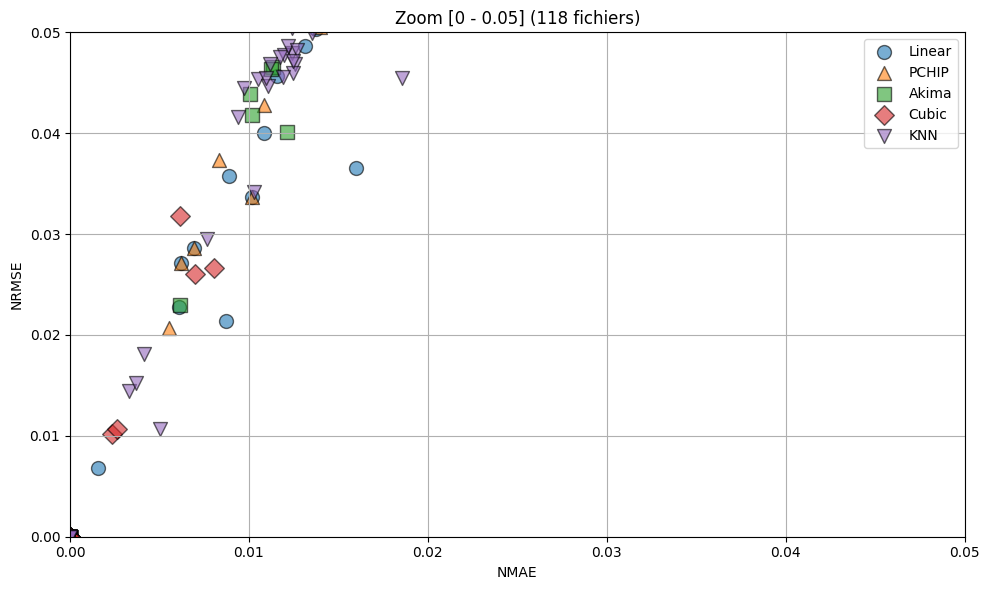

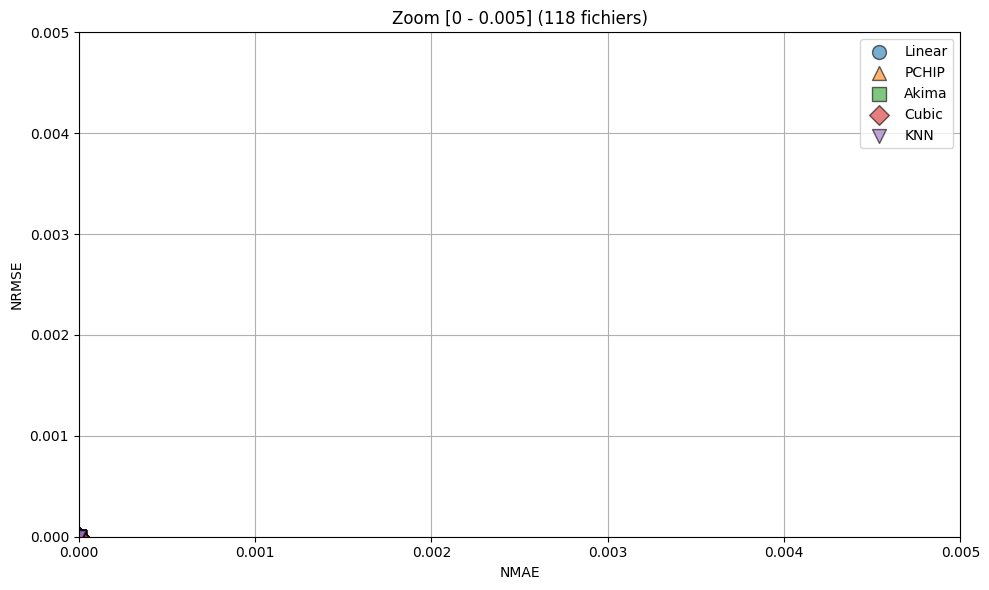

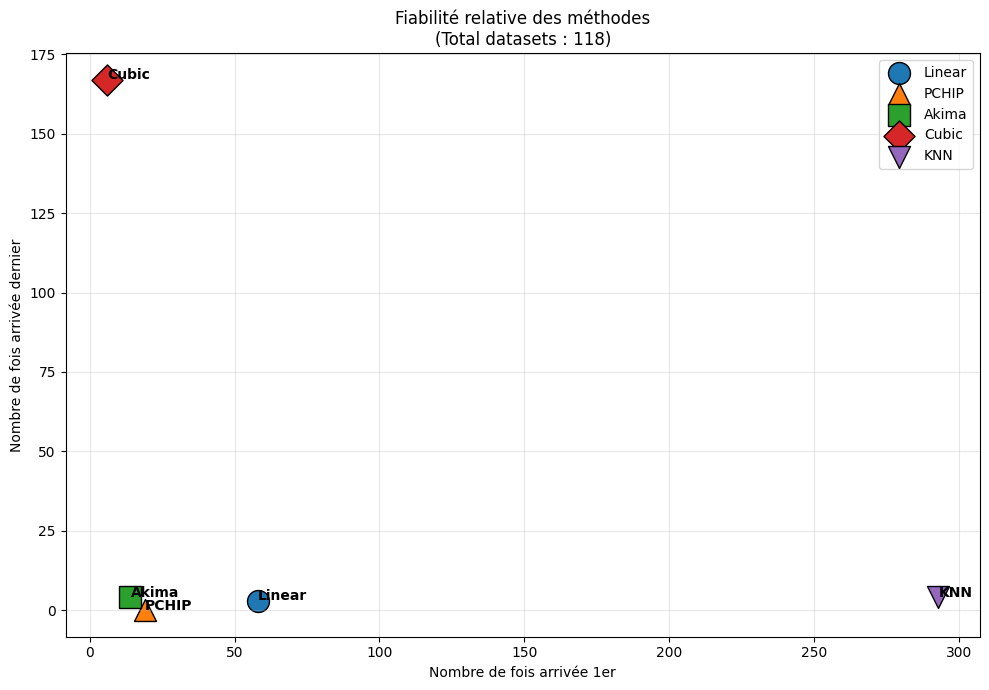

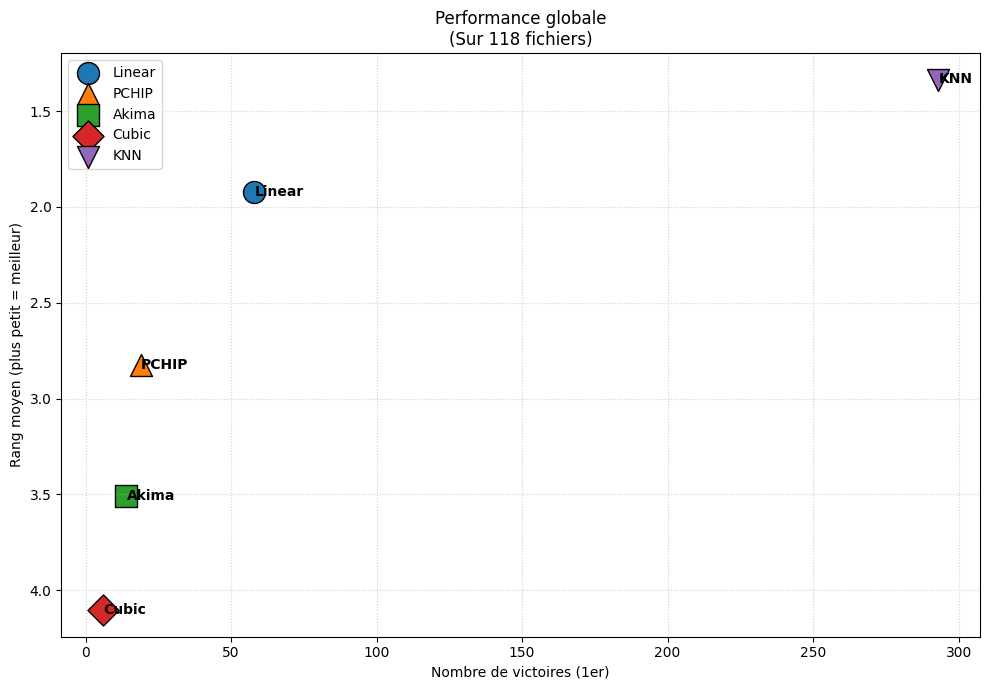

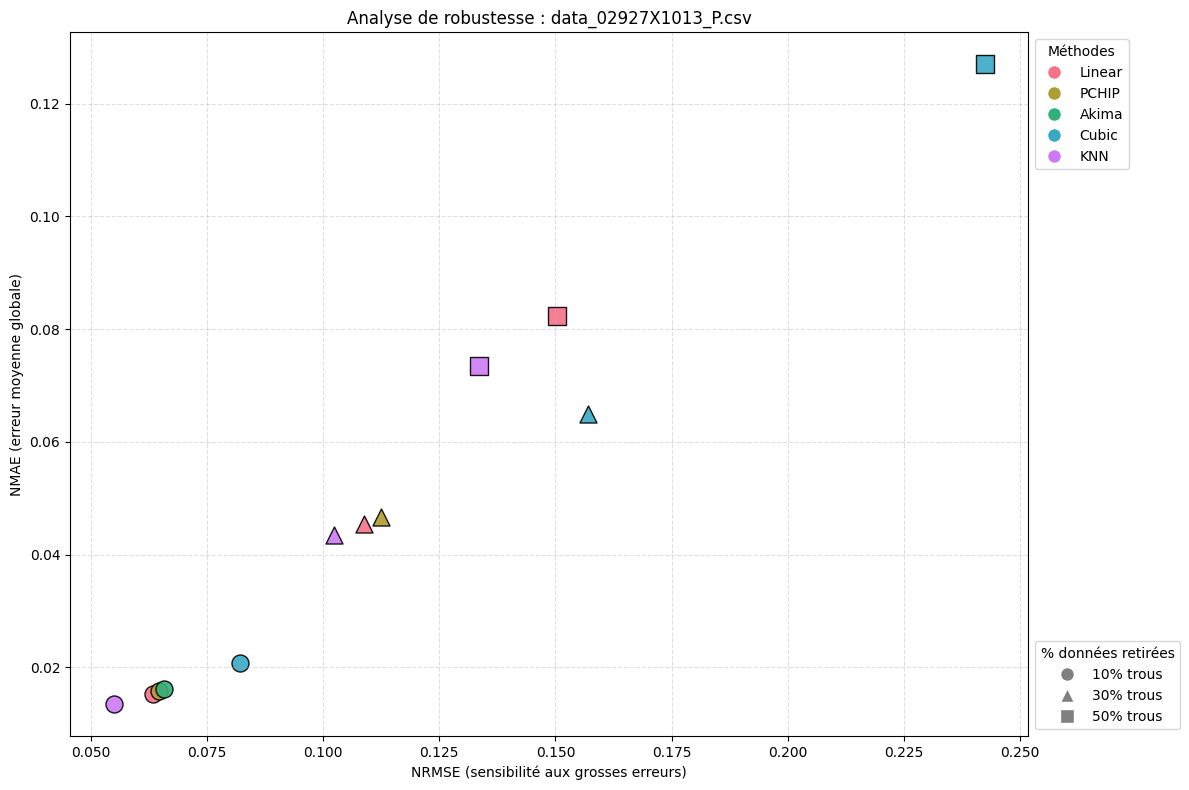





                            T_Q





⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.
⚠️ data_03295X1035_S1.csv ignoré : pas assez de points valides.
⚠️ data_03651X0043_S1.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.
⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.
⚠️ data_03295X1035_S1.csv ignoré : pas assez de points valides.
⚠️ data_03651X0043_S1.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.
⚠️ data_03273X0032_S1.csv ignoré : pas assez de points valides.
⚠️ data_03283X0057_F.csv ignoré : pas assez de points valides.
⚠️ data_03295X1035_S1.csv ignoré : pas assez de points valides.
⚠️ data_03651X0043_S1.csv ignoré : pas assez de points valides.
⚠️ data_03982X0027_P1.csv ignoré : pas assez de points valides.
⚠️ data_04002X0015_F1.csv ignoré : pas assez de points valides.


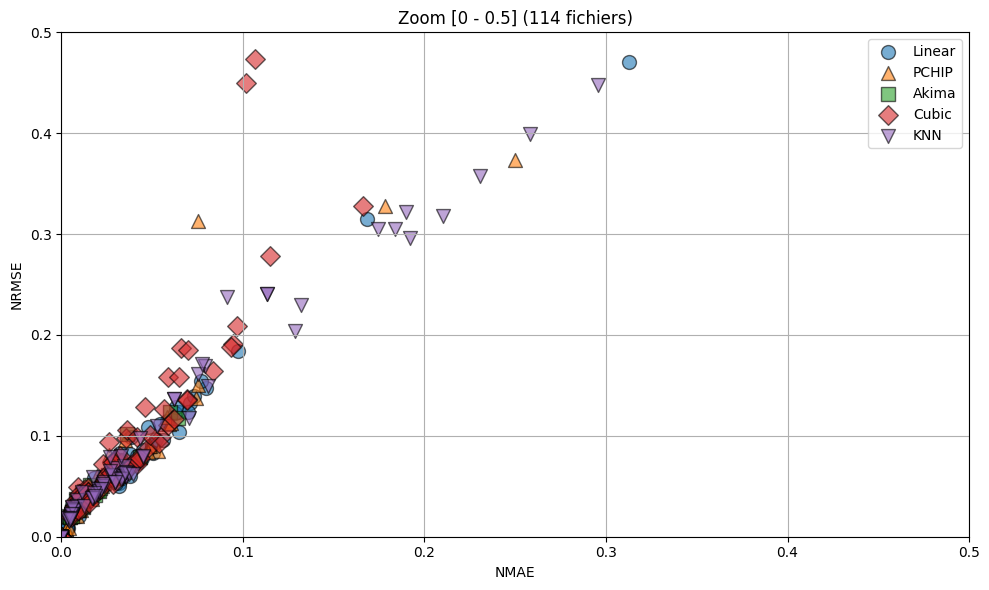

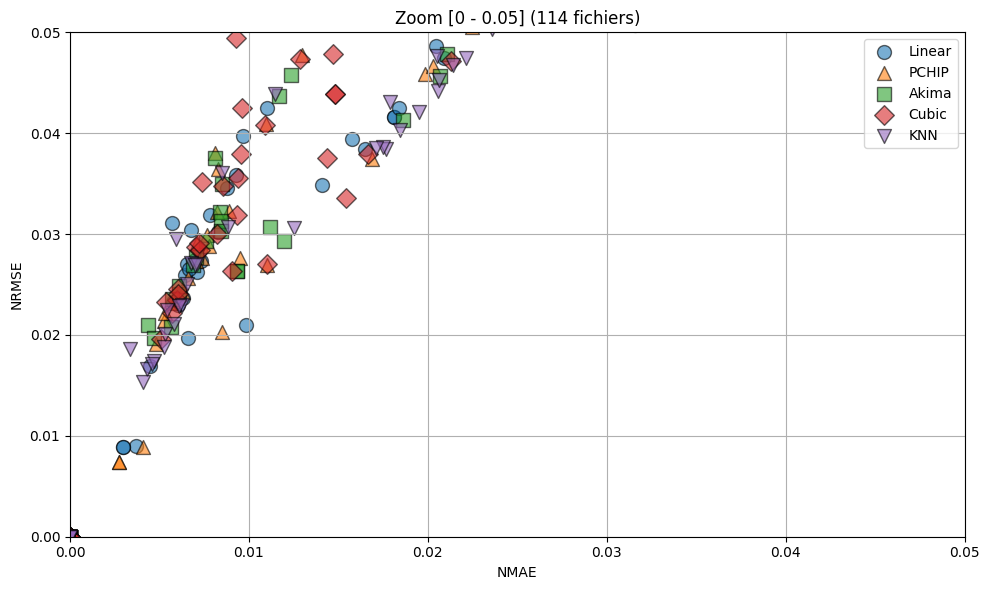

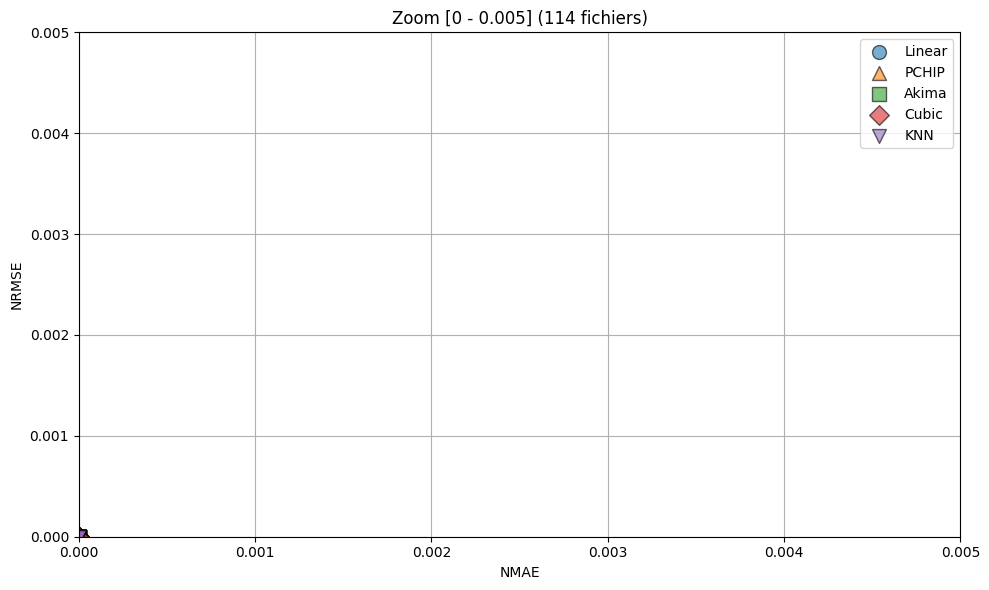

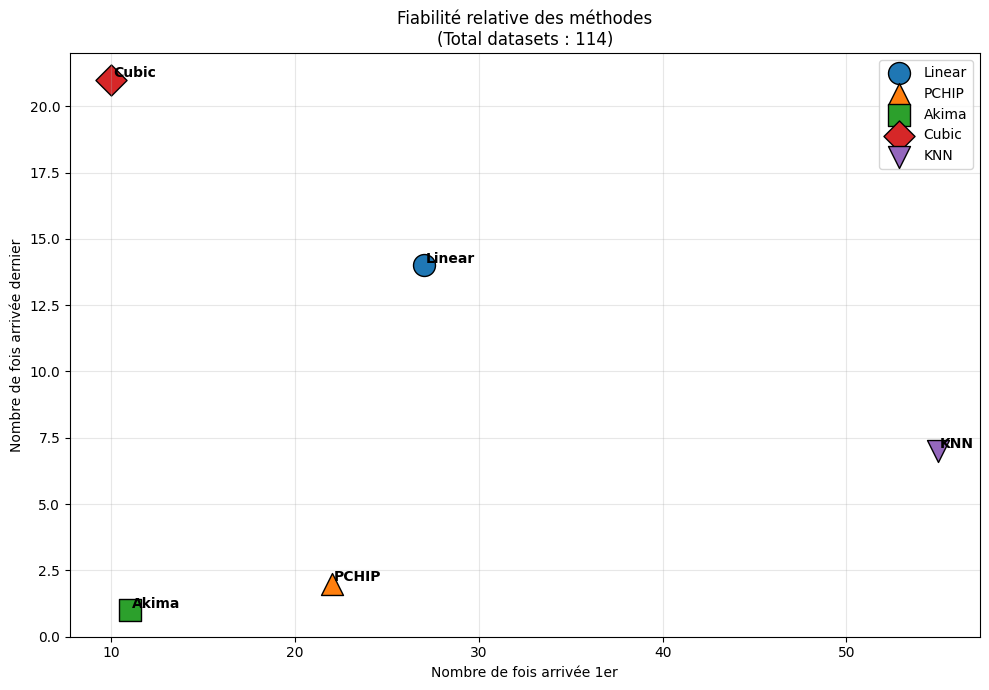

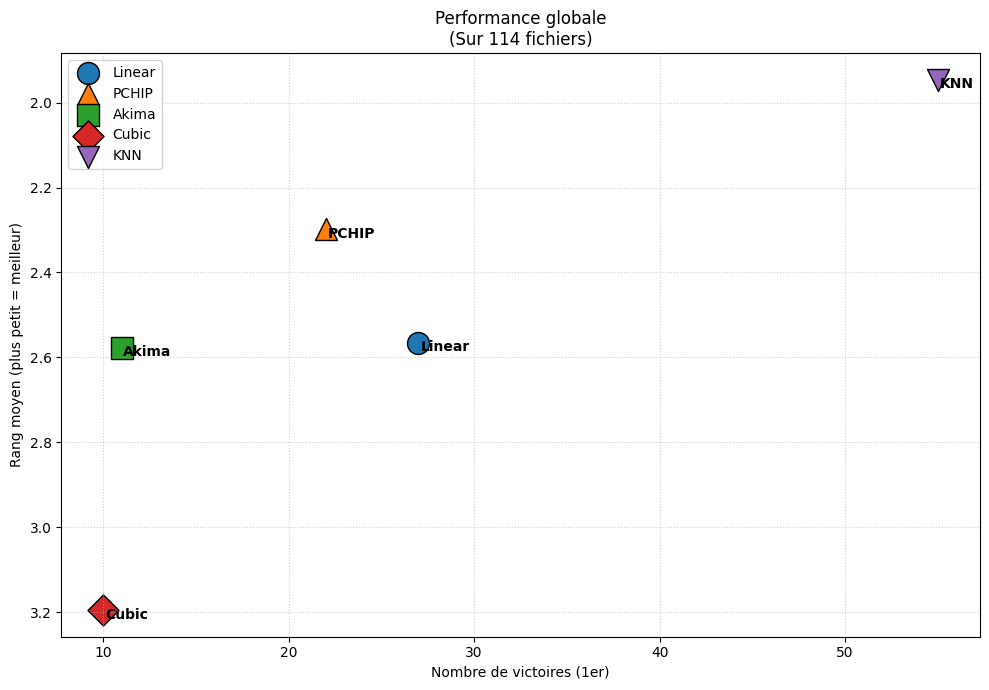

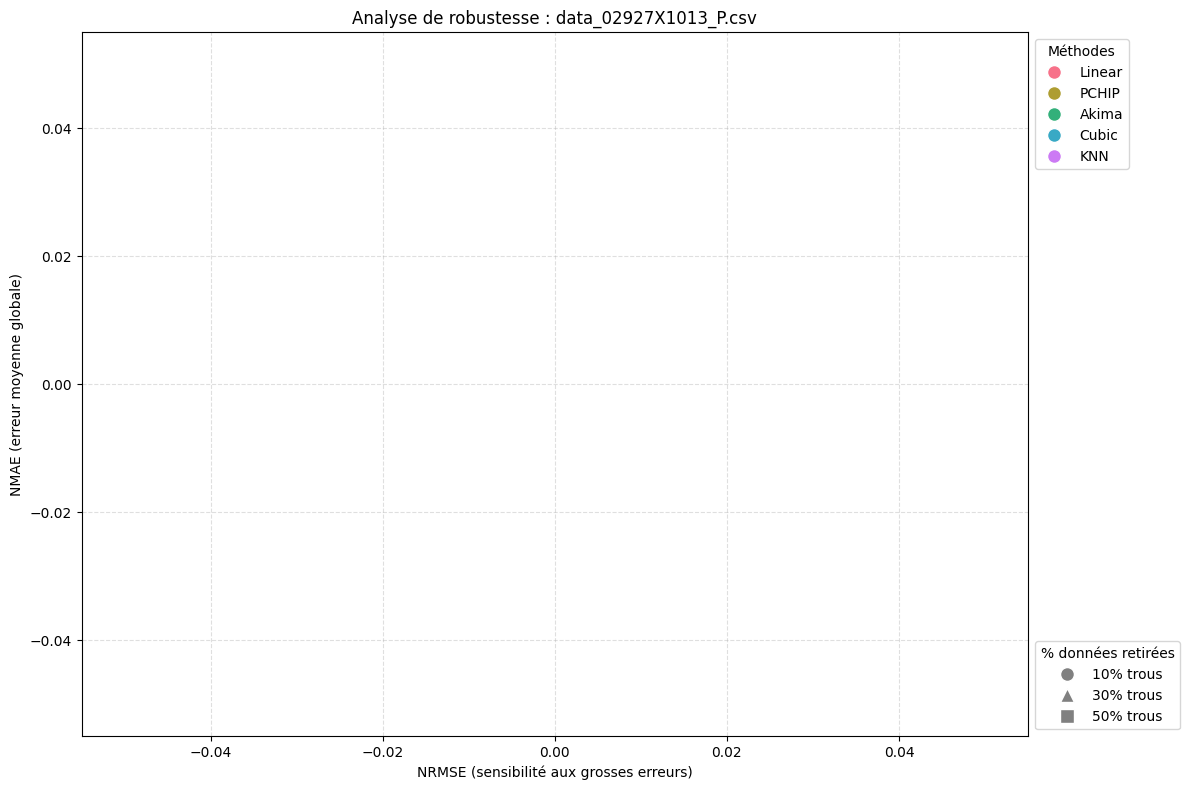

In [ ]:
# Suppose que tu as plusieurs DataFrames
# run_full_evaluation(dossier_nappe, valeur_de_travail, remove_pct_list=[0.1,0.3,0.5,0.8])

for elt in ["niveau_nappe_eau","ETP_Q","PRELIQ_Q","T_Q"] : run_full_evaluation(dossier_nappe, elt, remove_pct_list=[0.1,0.3,0.5]) 
